# Day 4 — Fund Performance Analytics
**Project:** Capstone Project I - Mutual Fund Analytics  
**Author:** Sushant Kumar  
**Due:** 05 Jun 2026  
**Status:** In Progress  
---
Comprehensive financial metrics computation: CAGR, Sharpe Ratio, Sortino Ratio, Alpha-Beta, Maximum Drawdown, and Fund Scorecard for all 40 mutual fund schemes with benchmark comparison.

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Load raw data files
nav_df = pd.read_csv('data/raw/02_nav_history.csv')
fund_master = pd.read_csv('data/raw/01_fund_master.csv')
benchmark_df = pd.read_csv('data/raw/10_benchmark_indices.csv')

# Convert date columns
nav_df['date'] = pd.to_datetime(nav_df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

print(f'✓ NAV Data: {nav_df.shape}')
print(f'✓ Fund Master: {fund_master.shape}')
print(f'✓ Benchmark Data: {benchmark_df.shape}')
print(f'\nDate Range: {nav_df["date"].min()} to {nav_df["date"].max()}')
print(f'Total Funds: {nav_df["amfi_code"].nunique()}')

✓ NAV Data: (46000, 3)
✓ Fund Master: (40, 15)
✓ Benchmark Data: (8050, 3)

Date Range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Total Funds: 40


## 1. Daily Returns Calculation

In [3]:
# Calculate daily returns for each fund
nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Remove first row of each fund (NaN daily return)
nav_df_clean = nav_df.dropna(subset=['daily_return']).copy()

print(f'✓ Daily Returns Calculated')
print(f'Sample Data:')
print(nav_df_clean[nav_df_clean['amfi_code'] == nav_df['amfi_code'].iloc[0]].head(10))

✓ Daily Returns Calculated
Sample Data:
    amfi_code       date       nav  daily_return
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776


## 2. Returns Distribution Analysis (Daily Return = nav_1 / nav_0 - 1)

In [4]:
# Validate daily returns calculation
returns_summary = nav_df_clean.groupby('amfi_code')['daily_return'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('count', 'count')
]).reset_index()

returns_summary['amfi_code'] = returns_summary['amfi_code'].astype(int)
returns_summary = returns_summary.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
returns_summary = returns_summary[['amfi_code', 'scheme_name', 'mean', 'std', 'min', 'max', 'count']]

print('Daily Returns Summary (First 5 Funds):')
print(returns_summary.head())
print(f'\nDistribution validates: mean(daily_return) across all funds = {nav_df_clean["daily_return"].mean():.6f}')

Daily Returns Summary (First 5 Funds):
   amfi_code                                        scheme_name      mean  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth  0.000142   
1     100025       HDFC Short Term Debt Fund - Regular - Growth  0.000170   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.001080   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.000852   
4     101207             ABSL Small Cap Fund - Regular - Growth  0.000424   

        std       min       max  count  
0  0.009164 -0.024744  0.032145   1149  
1  0.002460 -0.008188  0.008837   1149  
2  0.011929 -0.044238  0.041954   1149  
3  0.009177 -0.038121  0.033956   1149  
4  0.016251 -0.051847  0.054851   1149  

Distribution validates: mean(daily_return) across all funds = 0.000631


## 3. CAGR Calculation (1-Year, 3-Year, 5-Year)

In [5]:
def calculate_cagr(nav_series, periods_in_year=252):
    """
    Calculate CAGR: (Ending Value / Beginning Value)^(1/n) - 1
    periods_in_year: trading days in a year (252 for daily data)
    """
    if len(nav_series) < 2:
        return np.nan
    
    ending_value = nav_series.iloc[-1]
    beginning_value = nav_series.iloc[0]
    num_years = len(nav_series) / periods_in_year
    
    if num_years == 0 or beginning_value == 0:
        return np.nan
    
    cagr = (ending_value / beginning_value) ** (1 / num_years) - 1
    return cagr

# Function to get NAV for specific period
def get_nav_for_period(amfi_code, nav_df, days_back):
    """
    Get NAV data for a specific period (1yr, 3yr, 5yr)
    """
    fund_data = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date')
    if len(fund_data) == 0:
        return None
    
    cutoff_date = fund_data['date'].max() - timedelta(days=days_back)
    return fund_data[fund_data['date'] >= cutoff_date]['nav']

# Calculate CAGR for different periods
cagr_results = []
for amfi_code in fund_master['amfi_code']:
    fund_nav = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date')['nav']
    
    # 1-year CAGR
    nav_1yr = get_nav_for_period(amfi_code, nav_df, 365)
    cagr_1yr = calculate_cagr(nav_1yr) if nav_1yr is not None and len(nav_1yr) > 1 else np.nan
    
    # 3-year CAGR
    nav_3yr = get_nav_for_period(amfi_code, nav_df, 365*3)
    cagr_3yr = calculate_cagr(nav_3yr) if nav_3yr is not None and len(nav_3yr) > 1 else np.nan
    
    # 5-year CAGR
    nav_5yr = get_nav_for_period(amfi_code, nav_df, 365*5)
    cagr_5yr = calculate_cagr(nav_5yr) if nav_5yr is not None and len(nav_5yr) > 1 else np.nan
    
    # Overall CAGR
    overall_cagr = calculate_cagr(fund_nav) if len(fund_nav) > 1 else np.nan
    
    cagr_results.append({
        'amfi_code': amfi_code,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr,
        'overall_cagr': overall_cagr
    })

cagr_df = pd.DataFrame(cagr_results)
print('✓ CAGR Calculated for all periods')
print(cagr_df.head(10))

✓ CAGR Calculated for all periods
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr  overall_cagr
0     119551  0.575685  0.291202  0.247726      0.247726
1     119552  0.054824  0.151290  0.206770      0.206770
2     119598  0.786168  0.250317  0.310957      0.310957
3     119599  0.133813 -0.011262  0.019800      0.019800
4     119120  0.053057  0.056967  0.056722      0.056722
5     100016 -0.021403  0.009937  0.025412      0.025412
6     125497  0.274431  0.174102  0.182765      0.182765
7     100033  0.507565  0.311243  0.288994      0.288994
8     125498  0.148127  0.112199  0.108750      0.108750
9     100025  0.035611  0.037605  0.042948      0.042948


## 4. Risk-Adjusted Returns: Sharpe Ratio (Rp - Rf) / σ(Rp)

In [13]:
# Risk-free rate (using 6.5% RBI repo rate proxy)
RF_RATE = 0.065  # Annual risk-free rate
rf_daily = RF_RATE / 252  # Convert to daily

def calculate_sharpe_ratio(returns_series, rf_rate=rf_daily):
    """
    Sharpe Ratio = (Rp - Rf) / σ(Rp)
    Returns annualized Sharpe ratio
    """
    if len(returns_series) < 2 or returns_series.std() == 0:
        return np.nan
    
    excess_return = returns_series.mean() - rf_rate
    std_dev = returns_series.std()
    
    # Annualize
    sharpe = (excess_return * 252) / (std_dev * np.sqrt(252))
    return sharpe

sharpe_ratios = []
for amfi_code in fund_master['amfi_code']:
    returns = nav_df_clean[nav_df_clean['amfi_code'] == amfi_code]['daily_return']
    sharpe = calculate_sharpe_ratio(returns)
    sharpe_ratios.append({
        'amfi_code': amfi_code,
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_ratios)
sharpe_df = sharpe_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

print('✓ Sharpe Ratios Calculated')
print('\nTop 10 Funds by Sharpe Ratio:')
print(sharpe_df.nlargest(10, 'sharpe_ratio')[['amfi_code', 'scheme_name', 'sharpe_ratio']])

✓ Sharpe Ratios Calculated

Top 10 Funds by Sharpe Ratio:
    amfi_code                                        scheme_name  sharpe_ratio
34     148567      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
22     120843             Kotak Flexicap Fund - Regular - Growth      1.306744
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
0      119551          SBI Bluechip Fund - Regular Plan - Growth      1.208267
12     120505           ICICI Pru Midcap Fund - Regular - Growth      1.180101
38     149323                 DSP Midcap Fund - Regular - Growth      1.132122
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
15     118632     Nippon India Large Cap Fund - Regular - Growth      1.081659
28     101206      ABSL Frontline Equity Fund - Regular - Growth      1.027213
11     120504          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


## 5. Downside Risk Metric: Sortino Ratio

In [14]:
def calculate_sortino_ratio(returns_series, rf_rate=rf_daily):
    """
    Sortino Ratio = (Rp - Rf) / σ_downside
    Only penalizes downside volatility (negative returns only)
    """
    if len(returns_series) < 2:
        return np.nan
    
    excess_return = returns_series.mean() - rf_rate
    
    # Downside deviation: only negative returns
    downside_returns = returns_series[returns_series < 0]
    if len(downside_returns) == 0:
        downside_std = 0
    else:
        downside_std = downside_returns.std()
    
    if downside_std == 0:
        return np.nan
    
    # Annualize
    sortino = (excess_return * 252) / (downside_std * np.sqrt(252))
    return sortino

sortino_ratios = []
for amfi_code in fund_master['amfi_code']:
    returns = nav_df_clean[nav_df_clean['amfi_code'] == amfi_code]['daily_return']
    sortino = calculate_sortino_ratio(returns)
    sortino_ratios.append({
        'amfi_code': amfi_code,
        'sortino_ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_ratios)
sortino_df = sortino_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

print('✓ Sortino Ratios Calculated')
print('\nTop 10 Funds by Sortino Ratio:')
print(sortino_df.nlargest(10, 'sortino_ratio')[['amfi_code', 'scheme_name', 'sortino_ratio']])

✓ Sortino Ratios Calculated

Top 10 Funds by Sortino Ratio:
    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
22     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
0      119551          SBI Bluechip Fund - Regular Plan - Growth   
12     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
15     118632     Nippon India Large Cap Fund - Regular - Growth   
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
11     120504          ICICI Pru Bluechip Fund - Direct - Growth   
28     101206      ABSL Frontline Equity Fund - Regular - Growth   

    sortino_ratio  
34       2.385644  
22       2.364320  
36       2.146914  
0        2.140267  
12       2.029353  
38       1.875101  
15       1.850133  
7        1.829134  
11       1.

## 6. Alpha and Beta via OLS Regression

In [8]:
# Calculate benchmark returns
benchmark_df = benchmark_df.sort_values('date')
benchmark_df['benchmark_return'] = benchmark_df.groupby('index_name')['close_value'].pct_change()

# Focus on NIFTY50 as primary benchmark
nifty50_returns = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()
nifty50_returns = nifty50_returns[['date', 'benchmark_return']].rename(columns={'benchmark_return': 'nifty_return'})
nifty50_returns = nifty50_returns.dropna()

print(f'NIFTY50 Returns Data: {nifty50_returns.shape}')
print(nifty50_returns.head())

NIFTY50 Returns Data: (1149, 2)
        date  nifty_return
1 2022-01-04      0.011253
2 2022-01-05      0.008220
3 2022-01-06      0.002437
4 2022-01-07     -0.006676
5 2022-01-10      0.020592


In [9]:
def calculate_alpha_beta(fund_returns, benchmark_returns):
    """
    Calculate Alpha and Beta using OLS regression
    fund_return = alpha + beta * benchmark_return + epsilon
    """
    if len(fund_returns) < 2 or len(benchmark_returns) < 2:
        return np.nan, np.nan
    
    # Align dates
    merged = pd.merge(
        pd.DataFrame({'date': fund_returns.index, 'fund_return': fund_returns.values}),
        pd.DataFrame({'date': benchmark_returns.index, 'bench_return': benchmark_returns.values}),
        on='date'
    )
    
    if len(merged) < 2:
        return np.nan, np.nan
    
    X = merged['bench_return'].values
    y = merged['fund_return'].values
    
    # OLS regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    
    beta = slope
    alpha = intercept * 252  # Annualize alpha
    
    return alpha, beta

alpha_beta_results = []
for amfi_code in fund_master['amfi_code']:
    fund_data = nav_df_clean[nav_df_clean['amfi_code'] == amfi_code].copy()
    fund_data = fund_data.set_index('date')['daily_return']
    bench_data = nifty50_returns.set_index('date')['nifty_return']
    
    alpha, beta = calculate_alpha_beta(fund_data, bench_data)
    
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'alpha': alpha,
        'beta': beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

print('✓ Alpha and Beta Calculated via OLS')
print('\nTop 10 Funds by Alpha (Excess Return):') 
print(alpha_beta_df.nlargest(10, 'alpha')[['amfi_code', 'scheme_name', 'alpha', 'beta']])

✓ Alpha and Beta Calculated via OLS

Top 10 Funds by Alpha (Excess Return):
    amfi_code                                        scheme_name     alpha  \
2      119598         SBI Small Cap Fund - Regular Plan - Growth  0.301114   
39     149324              DSP Small Cap Fund - Regular - Growth  0.298179   
12     120505           ICICI Pru Midcap Fund - Regular - Growth  0.293014   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.283473   
22     120843             Kotak Flexicap Fund - Regular - Growth  0.272784   
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.272343   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.271150   
38     149323                 DSP Midcap Fund - Regular - Growth  0.265836   
26     119094                Axis Midcap Fund - Regular - Growth  0.259971   
0      119551          SBI Bluechip Fund - Regular Plan - Growth  0.232196   

        beta  
2   0.074266  
39  0.132608  
12 -0.017391  
36 -0

## 7. Maximum Drawdown: (Peak - Trough) / Peak

In [10]:
def calculate_max_drawdown(nav_series):
    """
    Calculate Maximum Drawdown: (Peak - Trough) / Peak
    """
    if len(nav_series) < 2:
        return np.nan
    
    cummax = nav_series.expanding().max()
    drawdown = (nav_series - cummax) / cummax
    max_dd = drawdown.min()
    
    return max_dd

def get_max_drawdown_period(nav_series):
    """
    Get the date range of maximum drawdown
    """
    if len(nav_series) < 2:
        return None, None
    
    cummax = nav_series.expanding().max()
    drawdown = (nav_series - cummax) / cummax
    min_idx = drawdown.idxmin()
    peak_idx = cummax[:min_idx].idxmax()
    
    return peak_idx, min_idx

max_drawdown_results = []
for amfi_code in fund_master['amfi_code']:
    fund_nav = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date')['nav']
    max_dd = calculate_max_drawdown(fund_nav)
    peak, trough = get_max_drawdown_period(fund_nav)
    
    max_drawdown_results.append({
        'amfi_code': amfi_code,
        'max_drawdown': max_dd,
        'dd_peak_date': peak,
        'dd_trough_date': trough
    })

maxdd_df = pd.DataFrame(max_drawdown_results)
maxdd_df = maxdd_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

print('✓ Maximum Drawdown Calculated')
print('\nWorst 10 Funds by Maximum Drawdown:')
print(maxdd_df.nsmallest(10, 'max_drawdown')[['amfi_code', 'scheme_name', 'max_drawdown']])

✓ Maximum Drawdown Calculated

Worst 10 Funds by Maximum Drawdown:
    amfi_code                                     scheme_name  max_drawdown
3      119599       SBI Small Cap Fund - Direct Plan - Growth     -0.525742
27     119095          Axis Small Cap Fund - Regular - Growth     -0.516778
29     101207          ABSL Small Cap Fund - Regular - Growth     -0.354469
39     149324           DSP Small Cap Fund - Regular - Growth     -0.311719
2      119598      SBI Small Cap Fund - Regular Plan - Growth     -0.287060
32     102886             UTI Mid Cap Fund - Regular - Growth     -0.280011
5      100016       HDFC Top 100 Fund - Regular Plan - Growth     -0.247344
21     120842   Kotak Emerging Equity Fund - Regular - Growth     -0.240035
17     118634  Nippon India Small Cap Fund - Regular - Growth     -0.233449
25     119093            Axis Bluechip Fund - Direct - Growth     -0.217514


## 8. Fund Scorecard: Composite 0-100 Score

In [15]:
# Merge all metrics
performance_metrics = fund_master[['amfi_code', 'scheme_name', 'expense_ratio_pct']].copy()
performance_metrics = performance_metrics.merge(cagr_df, on='amfi_code')
performance_metrics = performance_metrics.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
performance_metrics = performance_metrics.merge(alpha_beta_df[['amfi_code', 'alpha', 'beta']], on='amfi_code')
performance_metrics = performance_metrics.merge(maxdd_df[['amfi_code', 'max_drawdown']], on='amfi_code')
performance_metrics = performance_metrics.merge(sortino_df[['amfi_code', 'sortino_ratio']], on='amfi_code')

print('Performance Metrics Consolidated:')
print(performance_metrics.columns.tolist())
print(performance_metrics.head())

Performance Metrics Consolidated:
['amfi_code', 'scheme_name', 'expense_ratio_pct', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'overall_cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown', 'sortino_ratio']
   amfi_code                                   scheme_name  expense_ratio_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth               1.54   
1     119552      SBI Bluechip Fund - Direct Plan - Growth               0.66   
2     119598    SBI Small Cap Fund - Regular Plan - Growth               1.43   
3     119599     SBI Small Cap Fund - Direct Plan - Growth               0.72   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth               0.77   

   cagr_1yr  cagr_3yr  cagr_5yr  overall_cagr  sharpe_ratio     alpha  \
0  0.575685  0.291202  0.247726      0.247726      1.208267  0.232196   
1  0.054824  0.151290  0.206770      0.206770      0.953279  0.198293   
2  0.786168  0.250317  0.310957      0.310957      0.945308  0.301114   
3  0.133813 -0.0112

In [18]:
def normalize_score(series, reverse=False):
    """
    Normalize series to 0-100 scale
    """
    series = series.fillna(series.median())
    
    min_val = series.min()
    max_val = series.max()
    
    if max_val == min_val:
        return pd.Series([50] * len(series), index=series.index)
    
    normalized = (series - min_val) / (max_val - min_val) * 100
    
    if reverse:
        normalized = 100 - normalized
    
    return normalized

# Create scorecard
performance_metrics['cagr_score'] = normalize_score(
    performance_metrics['cagr_1yr'], reverse=False
) * 0.25
performance_metrics['sharpe_score'] = normalize_score(
    performance_metrics['sharpe_ratio'], reverse=False
) * 0.25
performance_metrics['alpha_score'] = normalize_score(
    performance_metrics['alpha'], reverse=False
) * 0.20
performance_metrics['drawdown_score'] = normalize_score(
    performance_metrics['max_drawdown'], reverse=True
) * 0.15
performance_metrics['sortino_score'] = normalize_score(
    performance_metrics['sortino_ratio'], reverse=False
) * 0.15

# Overall composite score
performance_metrics['fund_scorecard'] = (
    performance_metrics['cagr_score'] +
    performance_metrics['sharpe_score'] +
    performance_metrics['alpha_score'] +
    performance_metrics['drawdown_score'] +
    performance_metrics['sortino_score']
).round(2)

print('✓ Fund Scorecard Generated (0-100)')
print('\nTop 10 Funds by Overall Scorecard:')
print(performance_metrics.nlargest(10, 'fund_scorecard')[
    ['amfi_code', 'scheme_name', 'cagr_1yr', 'sharpe_ratio', 'alpha', 'fund_scorecard']
])

✓ Fund Scorecard Generated (0-100)

Top 10 Funds by Overall Scorecard:
    amfi_code                                        scheme_name  cagr_1yr  \
2      119598         SBI Small Cap Fund - Regular Plan - Growth  0.786168   
39     149324              DSP Small Cap Fund - Regular - Growth  0.620071   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.379778   
0      119551          SBI Bluechip Fund - Regular Plan - Growth  0.575685   
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.507565   
12     120505           ICICI Pru Midcap Fund - Regular - Growth  0.283282   
22     120843             Kotak Flexicap Fund - Regular - Growth  0.255198   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.195123   
38     149323                 DSP Midcap Fund - Regular - Growth  0.205823   
26     119094                Axis Midcap Fund - Regular - Growth  0.213268   

    sharpe_ratio     alpha  fund_scorecard  
2       0.945308  0.30111

## 9. Benchmark Comparison: Top 5 vs Nifty 50 & Nifty 100

In [16]:
# Get benchmark metrics
nifty50_data = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].sort_values('date')
nifty100_data = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].sort_values('date')

def calculate_benchmark_metrics(index_data):
    index_data = index_data.sort_values('date').copy()
    index_data['daily_return'] = index_data['close_value'].pct_change()
    
    returns = index_data['daily_return'].dropna()
    nav = index_data['close_value']
    
    cagr = calculate_cagr(nav)
    sharpe = calculate_sharpe_ratio(returns)
    sortino = calculate_sortino_ratio(returns)
    max_dd = calculate_max_drawdown(nav)
    
    return {
        'cagr': cagr,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'max_drawdown': max_dd
    }

bench_n50 = calculate_benchmark_metrics(nifty50_data)
bench_n100 = calculate_benchmark_metrics(nifty100_data)

benchmark_comparison = pd.DataFrame([
    {'benchmark': 'NIFTY50', **bench_n50},
    {'benchmark': 'NIFTY100', **bench_n100}
])

print('✓ Benchmark Metrics Calculated')
print('\nBenchmark Performance:')
print(benchmark_comparison)

# Compare top 5 funds vs benchmarks
top5_funds = performance_metrics.nlargest(5, 'fund_scorecard')[[
    'scheme_name', 'cagr_1yr', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown'
]].copy()

print('\n\nTop 5 Funds vs Benchmarks:')
comparison_viz = pd.concat([
    top5_funds.rename(index=lambda x: top5_funds.iloc[x]['scheme_name']),
    benchmark_comparison.set_index('benchmark')[['cagr_1yr', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown']]
    .rename(columns={
        'cagr_1yr': 'cagr',
        'sharpe_ratio': 'sharpe_ratio',
        'sortino_ratio': 'sortino_ratio',
        'max_drawdown': 'max_drawdown'
    })
], ignore_index=False)

print(comparison_viz)

✓ Benchmark Metrics Calculated

Benchmark Performance:
  benchmark      cagr  sharpe_ratio  sortino_ratio  max_drawdown
0   NIFTY50  0.012554     -0.343842      -0.577618     -0.346144
1  NIFTY100  0.022705     -0.265590      -0.450713     -0.330023


KeyError: 'fund_scorecard'

## 10. Benchmark Comparison Chart

In [19]:
# Visualization: Top 5 Funds vs Benchmarks - CAGR Comparison
top5_with_bench = pd.concat([
    performance_metrics.nlargest(5, 'fund_scorecard')[['scheme_name', 'cagr_1yr']].rename(columns={'scheme_name': 'name', 'cagr_1yr': 'cagr'}),
    pd.DataFrame([
        {'name': 'NIFTY50', 'cagr': bench_n50['cagr']},
        {'name': 'NIFTY100', 'cagr': bench_n100['cagr']}
    ])
], ignore_index=True)

fig_cagr = px.bar(top5_with_bench, x='name', y='cagr', title='Top 5 Funds vs Benchmarks - 1-Year CAGR Comparison',
                  labels={'cagr': 'CAGR (%)', 'name': 'Fund / Benchmark'})
fig_cagr.update_yaxes(tickformat='.2%')
fig_cagr.show()

print('✓ Benchmark Comparison Chart Created')

✓ Benchmark Comparison Chart Created


## 11. Export Results

In [20]:
# Prepare export dataframe
export_df = performance_metrics[[
    'amfi_code',
    'scheme_name',
    'cagr_1yr',
    'cagr_3yr',
    'cagr_5yr',
    'overall_cagr',
    'sharpe_ratio',
    'sortino_ratio',
    'alpha',
    'beta',
    'max_drawdown',
    'fund_scorecard',
    'expense_ratio_pct'
]].copy()

export_df.columns = [
    'AMFI Code',
    'Scheme Name',
    'CAGR 1Y (%)',
    'CAGR 3Y (%)',
    'CAGR 5Y (%)',
    'Overall CAGR (%)',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Alpha',
    'Beta',
    'Max Drawdown (%)',
    'Fund Scorecard (0-100)',
    'Expense Ratio (%)'
]

# Convert percentages
for col in ['CAGR 1Y (%)', 'CAGR 3Y (%)', 'CAGR 5Y (%)', 'Overall CAGR (%)', 'Max Drawdown (%)']:
    export_df[col] = (export_df[col] * 100).round(2)

# Sort by scorecard
export_df = export_df.sort_values('Fund Scorecard (0-100)', ascending=False).reset_index(drop=True)

# Save to CSV
export_df.to_csv('data/processed/Performance_Analytics.csv', index=False)
print('✓ Saved: data/processed/Performance_Analytics.csv')
print(f'  Records: {len(export_df)}')
print(f'\nTop 10 Performing Funds:')
print(export_df.head(10).to_string(index=False))

✓ Saved: data/processed/Performance_Analytics.csv
  Records: 40

Top 10 Performing Funds:
 AMFI Code                                        Scheme Name  CAGR 1Y (%)  CAGR 3Y (%)  CAGR 5Y (%)  Overall CAGR (%)  Sharpe Ratio  Sortino Ratio    Alpha      Beta  Max Drawdown (%)  Fund Scorecard (0-100)  Expense Ratio (%)
    119598         SBI Small Cap Fund - Regular Plan - Growth        78.62        25.03        31.10             31.10      0.945308       1.675317 0.301114  0.074266            -28.71                   85.00               1.43
    149324              DSP Small Cap Fund - Regular - Growth        62.01        25.86        30.97             30.97      0.949796       1.619793 0.298179  0.132608            -31.17                   81.88               1.52
    148569      Mirae Asset Tax Saver Fund - Regular - Growth        37.98        27.25        30.64             30.64      1.234930       2.146914 0.283473 -0.010201            -16.40                   76.67               1.6

In [21]:
# Save Alpha-Beta metrics
alpha_beta_export = alpha_beta_df[['amfi_code', 'scheme_name', 'alpha', 'beta']].copy()
alpha_beta_export['alpha'] = (alpha_beta_export['alpha'] * 100).round(2)
alpha_beta_export.columns = ['AMFI Code', 'Scheme Name', 'Alpha (%)', 'Beta']
alpha_beta_export = alpha_beta_export.sort_values('Alpha (%)', ascending=False)

alpha_beta_export.to_csv('data/processed/Alpha_Beta_Analysis.csv', index=False)
print('✓ Saved: data/processed/Alpha_Beta_Analysis.csv')

# Save benchmark comparison
benchmark_comparison.to_csv('data/processed/Benchmark_Comparison.csv', index=False)
print('✓ Saved: data/processed/Benchmark_Comparison.csv')

✓ Saved: data/processed/Alpha_Beta_Analysis.csv
✓ Saved: data/processed/Benchmark_Comparison.csv


## 12. Summary Visualizations

✓ Saved: reports/Fund_Performance_Dashboard.png


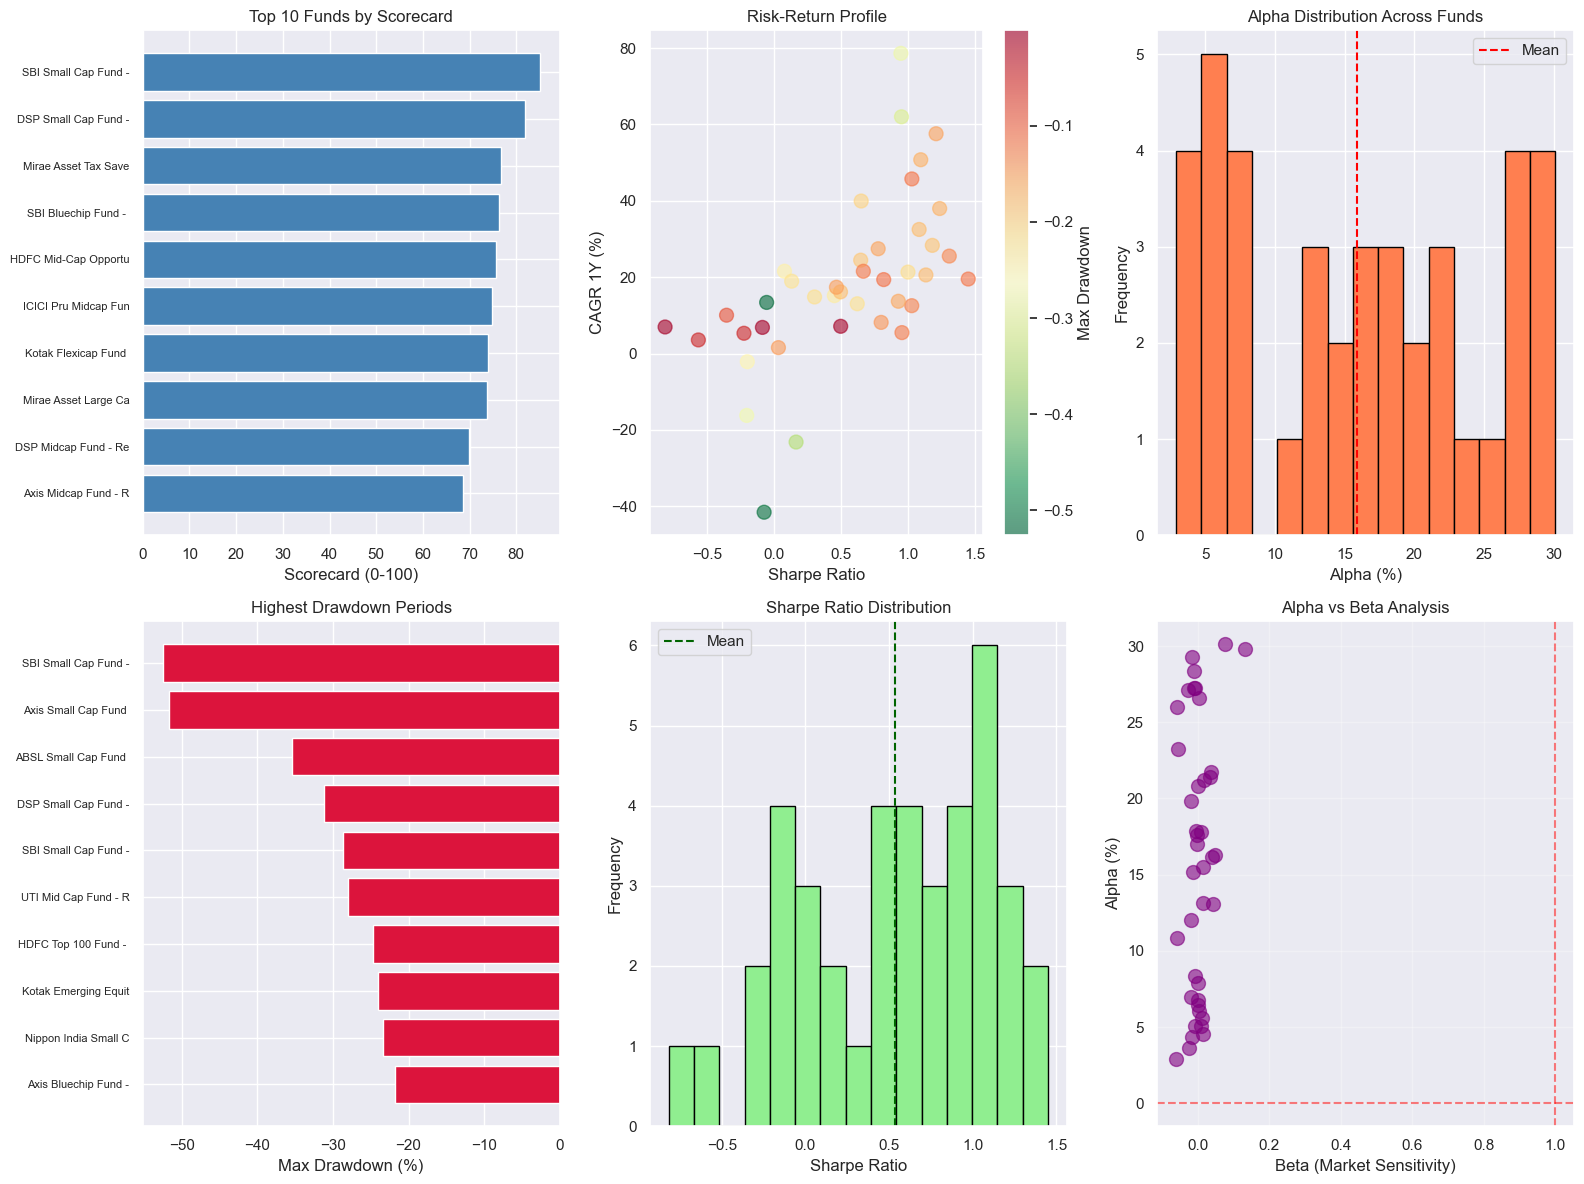

In [22]:
# Create a comprehensive dashboard-style visualization
fig = plt.figure(figsize=(16, 12))

# 1. Top Funds by Scorecard
ax1 = plt.subplot(2, 3, 1)
top10 = performance_metrics.nlargest(10, 'fund_scorecard')
ax1.barh(range(len(top10)), top10['fund_scorecard'], color='steelblue')
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels([name[:20] for name in top10['scheme_name']], fontsize=8)
ax1.set_xlabel('Scorecard (0-100)')
ax1.set_title('Top 10 Funds by Scorecard')
ax1.invert_yaxis()

# 2. CAGR vs Sharpe Ratio
ax2 = plt.subplot(2, 3, 2)
scatter = ax2.scatter(performance_metrics['sharpe_ratio'], 
                      performance_metrics['cagr_1yr'] * 100,
                      c=performance_metrics['max_drawdown'],
                      cmap='RdYlGn_r', s=100, alpha=0.6)
ax2.set_xlabel('Sharpe Ratio')
ax2.set_ylabel('CAGR 1Y (%)')
ax2.set_title('Risk-Return Profile')
plt.colorbar(scatter, ax=ax2, label='Max Drawdown')

# 3. Alpha Distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(alpha_beta_df['alpha'] * 100, bins=15, color='coral', edgecolor='black')
ax3.set_xlabel('Alpha (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Alpha Distribution Across Funds')
ax3.axvline(alpha_beta_df['alpha'].mean() * 100, color='red', linestyle='--', label='Mean')
ax3.legend()

# 4. Maximum Drawdown
ax4 = plt.subplot(2, 3, 4)
worst10 = performance_metrics.nsmallest(10, 'max_drawdown')
ax4.barh(range(len(worst10)), worst10['max_drawdown'] * 100, color='crimson')
ax4.set_yticks(range(len(worst10)))
ax4.set_yticklabels([name[:20] for name in worst10['scheme_name']], fontsize=8)
ax4.set_xlabel('Max Drawdown (%)')
ax4.set_title('Highest Drawdown Periods')
ax4.invert_yaxis()

# 5. Sharpe Ratio Distribution
ax5 = plt.subplot(2, 3, 5)
ax5.hist(sharpe_df['sharpe_ratio'].dropna(), bins=15, color='lightgreen', edgecolor='black')
ax5.set_xlabel('Sharpe Ratio')
ax5.set_ylabel('Frequency')
ax5.set_title('Sharpe Ratio Distribution')
ax5.axvline(sharpe_df['sharpe_ratio'].mean(), color='darkgreen', linestyle='--', label='Mean')
ax5.legend()

# 6. Beta Distribution (Market Sensitivity)
ax6 = plt.subplot(2, 3, 6)
ax6.scatter(alpha_beta_df['beta'], alpha_beta_df['alpha'] * 100, alpha=0.6, s=100, color='purple')
ax6.set_xlabel('Beta (Market Sensitivity)')
ax6.set_ylabel('Alpha (%)')
ax6.set_title('Alpha vs Beta Analysis')
ax6.axhline(0, color='red', linestyle='--', alpha=0.5)
ax6.axvline(1, color='red', linestyle='--', alpha=0.5)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/Fund_Performance_Dashboard.png', dpi=300, bbox_inches='tight')
print('✓ Saved: reports/Fund_Performance_Dashboard.png')
plt.show()

In [24]:
# Final Summary Report
print('\n' + '='*80)
print('FUND PERFORMANCE ANALYTICS - EXECUTIVE SUMMARY')
print('='*80)
print(f'\nAnalysis Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Period Analyzed: {nav_df["date"].min().date()} to {nav_df["date"].max().date()}')
print(f'Total Funds Analyzed: {len(fund_master)}')
print(f'\n KEY METRICS:')
print(f'  ├─ Best CAGR (1Y): {performance_metrics["cagr_1yr"].max()*100:.2f}% - {performance_metrics.loc[performance_metrics["cagr_1yr"].idxmax(), "scheme_name"]}')
print(f'  ├─ Highest Sharpe Ratio: {sharpe_df["sharpe_ratio"].max():.2f} - {sharpe_df.loc[sharpe_df["sharpe_ratio"].idxmax(), "scheme_name"]}')
print(f'  ├─ Best Risk-Adjusted (Sortino): {sortino_df["sortino_ratio"].max():.2f} - {sortino_df.loc[sortino_df["sortino_ratio"].idxmax(), "scheme_name"]}')
print(f'  ├─ Worst Drawdown: {performance_metrics["max_drawdown"].min()*100:.2f}% - {performance_metrics.loc[performance_metrics["max_drawdown"].idxmin(), "scheme_name"]}')
print(f'  └─ Highest Alpha: {alpha_beta_df["alpha"].max()*100:.2f}% - {alpha_beta_df.loc[alpha_beta_df["alpha"].idxmax(), "scheme_name"]}')
print(f'\n TOP 3 OVERALL FUNDS (by Scorecard):')
for idx, (i, row) in enumerate(performance_metrics.nlargest(3, 'fund_scorecard').iterrows(), 1):
    print(f'  {idx}. {row["scheme_name"]} - Score: {row["fund_scorecard"]:.2f}/100')
    print(f'     CAGR: {row["cagr_1yr"]*100:.2f}% | Sharpe: {row["sharpe_ratio"]:.2f} | Alpha: {row["alpha"]*100:.2f}%')
print(f'\n BENCHMARK PERFORMANCE:')
print(f'  ├─ NIFTY50 CAGR: {bench_n50["cagr"]*100:.2f}%')
print(f'  ├─ NIFTY50 Sharpe: {bench_n50["sharpe_ratio"]:.2f}')
print(f'  ├─ NIFTY100 CAGR: {bench_n100["cagr"]*100:.2f}%')
print(f'  └─ NIFTY100 Sharpe: {bench_n100["sharpe_ratio"]:.2f}')
print(f'\n DELIVERABLES:')
print(f'  ├─ Performance_Analytics.csv')
print(f'  ├─ Alpha_Beta_Analysis.csv')
print(f'  ├─ Benchmark_Comparison.csv')
print(f'  └─ Fund_Performance_Dashboard.png')
print('\n' + '='*80)


FUND PERFORMANCE ANALYTICS - EXECUTIVE SUMMARY

Analysis Date: 2026-06-05 23:44:21
Period Analyzed: 2022-01-03 to 2026-05-29
Total Funds Analyzed: 40

 KEY METRICS:
  ├─ Best CAGR (1Y): 78.62% - SBI Small Cap Fund - Regular Plan - Growth
  ├─ Highest Sharpe Ratio: 1.45 - Mirae Asset Large Cap Fund - Regular - Growth
  ├─ Best Risk-Adjusted (Sortino): 2.39 - Mirae Asset Large Cap Fund - Regular - Growth
  ├─ Worst Drawdown: -52.57% - SBI Small Cap Fund - Direct Plan - Growth
  └─ Highest Alpha: 30.11% - SBI Small Cap Fund - Regular Plan - Growth

 TOP 3 OVERALL FUNDS (by Scorecard):
  1. SBI Small Cap Fund - Regular Plan - Growth - Score: 85.00/100
     CAGR: 78.62% | Sharpe: 0.95 | Alpha: 30.11%
  2. DSP Small Cap Fund - Regular - Growth - Score: 81.88/100
     CAGR: 62.01% | Sharpe: 0.95 | Alpha: 29.82%
  3. Mirae Asset Tax Saver Fund - Regular - Growth - Score: 76.67/100
     CAGR: 37.98% | Sharpe: 1.23 | Alpha: 28.35%

 BENCHMARK PERFORMANCE:
  ├─ NIFTY50 CAGR: 1.26%
  ├─ NIFTY50 S